# Distance-map experiments

This notebook builds weighted distributions on simplex fundamental domains, then maps those samples into 2D polygons and 3D polyhedra with piecewise affine maps.

The main workflow is:

1. Define a scalar field and symmetry operations.
2. Symmetrize the field over a grid.
3. Sample a weighted distribution on a simplex.
4. Search candidate piecewise maps and minimize the Jacobian/Dirichlet-style energy.
5. Visualize the original and transformed distributions.

The symmetrized field is

$$f_{sym}(x_1, ..., x_n) = \frac{1}{|G|} \sum_{g \in G} f(g\cdot(x_1, ..., x_n))$$

where this function is the Reynolds average, or the trivial-representation projector, since it projects onto the trivial representation (transforms trivially).

In [1]:
from os import environ
from pathlib import Path
import sys

environ["OPENBLAS_NUM_THREADS"] = "1"
environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

_project_root = Path.cwd().resolve()
# print(_project_root, *_project_root.parents)
sys.path.insert(0, str(_project_root.parents[0]))
# for _candidate in (_project_root, *_project_root.parents):
# 	if (_candidate / "crystal_funcs.py").exists():
# 		if str(_candidate) not in sys.path:
# 			sys.path.insert(0, str(_candidate))
# 		break
# else:
# 	raise RuntimeError("Could not locate project root containing crystal_funcs.py")

import dataclasses as dcls
from collections.abc import Callable
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import numpy as onp
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import ConvexHull
import src.crystal_funcs as cfuncs
from plotting_utils import plot_func, plot_result, plot_simplex, plot_weighted_dist
from TriMap import TriMap, define_distribution
import src.coordinates as cconv
import src.symmetry as sym
from src.categorization import print_symmetry_operations

onp.set_printoptions(precision=2, suppress=True)
NDArray = onp.ndarray



Config
----
***

In [2]:
@dcls.dataclass(frozen=True)
class Config:
	seed: int = 0
	res_2d: int = 200
	res_3d: int = 50

	n_samples_fast: int = 5_000
	n_samples_plot: int = 10_000

from src.bases import CanonBasis3, CanonBasis2

cmap = plt.get_cmap("afmhot").copy()
cmap.set_bad(color="whitesmoke")


cfg = Config()
B = CanonBasis3()
B2 = CanonBasis2()

2D
----
***

In [3]:
def func6(*xi):
	x,y = xi
	return x**6 + x**5*y + x**4*y**2 + x**3*y**3 + x**2*y**4 + x*y**5 + y**6


def func5(*xi):
	x,y = xi
	return x**5 + x**4*y + x**3*y**2 + x**2*y**3 + x*y**4 + y**7

def func4(*xi):
	x,y = xi
	return x**4 + x**3*y + x**2*y**2 + x*y**4 + y**7

def func3(*xi):
	x,y = xi
	return x**3 + x**2*y + x*y**2 + y**5

def func2(*xi):
	x,y = xi
	return onp.cos(2 * onp.pi * x**2) + onp.sin(onp.pi*y**2)

def func_xy(*xi):
	x, y = xi
	return x * y

Expect to see func_xy fail:
- Reflection across $y$ gives $(x,y)\mapsto (-x,y)$, and $(-x)y=-xy$
- in Reynolds average, every term $f(x,y)$ is also paired with its negation $-f(x,y)$, so the average should be zero

**r(0)**

<IPython.core.display.Math object>

---

**r(1.5708)**

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

---

**s**

<IPython.core.display.Math object>

---

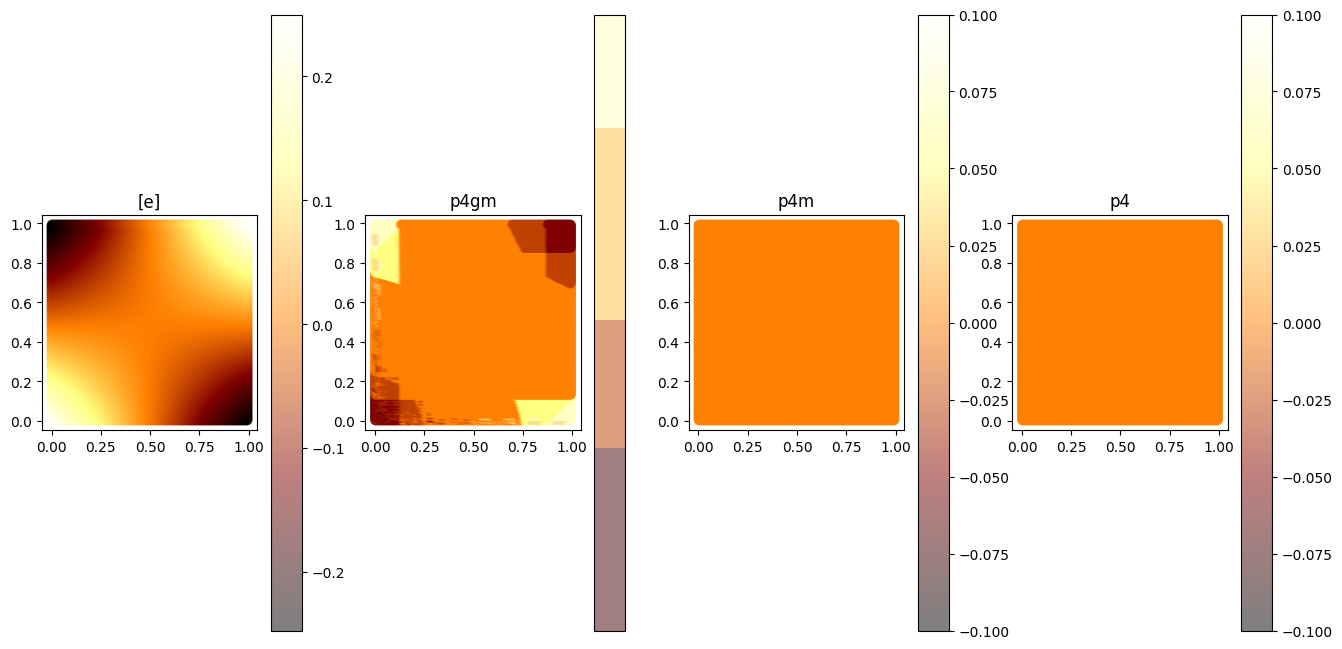

In [5]:
ndim = 2
_0 = onp.zeros(ndim)
domain = onp.array([(0, 1)] * ndim)
center = 0.5 * (domain[:, 1] - domain[:, 0])

# ---- build grid
xi = onp.array([
	onp.linspace(d[0], d[1], cfg.res_2d, endpoint=False) for d in domain
], dtype=onp.float32) 

# center
xi = xi - center[:, None]

grid = onp.meshgrid(*xi)
coords = onp.vstack([x.ravel() for x in grid]).T + center
coords.astype(onp.float32)


# Group operations
rot_order = 4
p4 = [sym.rotation2d(i * 2 * onp.pi / rot_order) for i in range(rot_order)]
# Glide reflections
gl_ref = sym.glide_reflection
g = [
	gl_ref(B2.e1, center),
	gl_ref(B2.e2, center),
	gl_ref(B2.e1 - B2.e2, center),
	gl_ref(B2.e1 + B2.e2, center),
]

# Reflections
ref = sym.reflection
m = [
	ref(B2.e2),
	ref(B2.e1),
	ref(B2.e1 - B2.e2),
	ref(B2.e1 + B2.e2),
]

# TODO better way to combine groups
Gp4 = sym.FiniteGroupAction(tuple(p4), name="p4")
Gp4m = sym.FiniteGroupAction((*p4, *m), name="p4m")
Gp4gm = sym.FiniteGroupAction((*p4, *g, *m), name="p4gm")
print_symmetry_operations(Gp4gm)
plot_func(func_xy, *grid, center=center, sym_ops=[Gp4gm, Gp4m, Gp4])

# TODO compute these from the symmetry group
fundamental_units = [
	0.5 * onp.array([(1, 0), (1, 1), (0, 1)]),
	0.5 * onp.array([(1, 0), (1, 1), (0, 1)]),
	0.5 * onp.array([(1, 0), (1, 1), (0, 0)]),
	0.5 * onp.array([(1, 0), (1, 1), (0, 1)]),
]


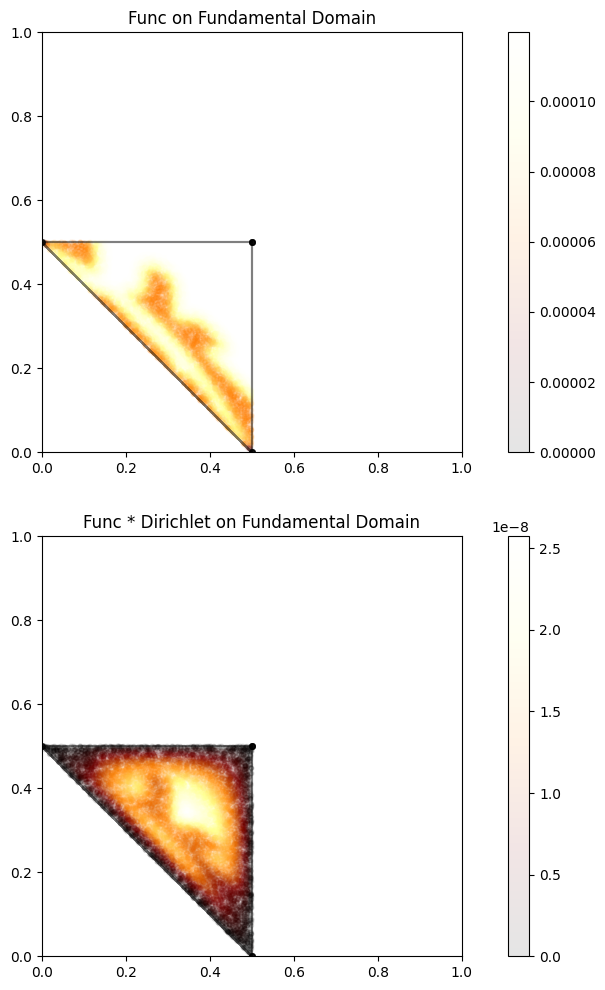

In [ ]:
test_polygon_verts: list[tuple[float, float]] = [
	(1, 0),
	(0.62, 0.78),
	(-0.22, 1),
	(-0.90, 0.2),
	(-0.90, -0.43),
	(-0.22, -0.97),
	(0.62, -0.78),
]

test_unit_verts = [
	(0.5, 0), 
	(0.5, 0.5), 
	(0, 0.5)
]

test_unit = onp.array(test_unit_verts)
test_unit_cent = cfuncs.centroid(test_unit)
polygon = onp.array(test_polygon_verts)

f_sym = sym.symmetrize(func_xy, *grid, sym_ops=[*p4, *g, *m])
plot_weighted_dist(f_sym, coords.T, test_unit, n_samples=cfg.n_samples_plot, rng=cfg.seed + 1)


In [ ]:
f_sym = sym.symmetrize(func2, *grid, sym_ops=[*p4, *g, *m])
dist, dist_w = cfuncs.weighted_distribution(
    f_sym,
    coords.T,
    test_unit,
    n_samples=cfg.n_samples_fast,
    rng=cfg.seed + 2,
)

dir_pts = cconv.calculate_barycentric_coordinates(test_unit, dist)
dir_w = cconv.barycentric_weights(dir_pts)
assert onp.allclose(dir_pts.sum(axis=1), 1)
assert onp.all(dir_pts >= -1e-10)

centered_dist = dist - test_unit_cent
total_weights = dist_w * dir_w
total_weights = total_weights / total_weights.sum()

assert onp.all(onp.isfinite(total_weights))
assert onp.all(total_weights >= 0)
assert onp.isclose(total_weights.sum(), 1)

tri_map = TriMap(polygon, test_unit)
define_distribution(tri_map.triangle, tri_map.dim, distribution=dir_pts, distribution_weights=total_weights)
tri_map.create_mapping()
idx = tri_map.minimize_jacobian()

# TODO better naming
best_map = tri_map.maps[idx]
best_mats = tri_map.matrices[idx]
best_poly = tri_map.rotated_polygons[idx]
best_tri = tri_map.triangulations[idx]
dist = cconv.bary_to_cart(dir_pts, tri_map.triangle)

plot_result(best_map, best_mats, best_poly, best_tri, centered_dist, total_weights)


In [ ]:
#
max_deg = 10

def weighting(x, alpha) -> onp.ndarray:
	return onp.exp(-alpha * x)

def collect_pts(poly, best_poly):
	num = len(poly)
	edges = [cfuncs.edge_func(poly[i], poly[(i+1)%num]) for i in range(num)]
	edges = onp.vstack(edges)
	return onp.vstack([edges] + list(best_poly))


best_poly_cropped = best_poly[:-1]
src_pts = collect_pts(best_poly_cropped, best_poly)


best_map_cropped = best_map[:-1]
trg_pts = collect_pts(best_map_cropped, best_map)

# TODO??? is this just making tha map wll defined?
_, src_idx = onp.unique(src_pts, axis=0, return_index=True)
src_pts = src_pts[src_idx]
trg_pts = trg_pts[src_idx]

_, dst_idx = onp.unique(trg_pts, axis=0, return_index=True)
src_pts = src_pts[dst_idx]
trg_pts = trg_pts[dst_idx]


# in the target/fundamental-domain coordinates
dist = cconv.barycentric_to_cartesian_2D(tri_map.distribution, tri_map.triangle)
# map from triangle to polygon
coeffs = cfuncs.compute_coefficients(trg_pts, src_pts, max_deg)
coeffs_x, coeffs_y = coeffs
inv_basis = cfuncs.polynomial_basis((dist[:,0], dist[:,1]), max_deg)
# u, v = onp.sum(coeffs_x * inv_basis.T, axis=1), onp.sum(coeffs_y * inv_basis.T, axis=1)
nonlinear_map = onp.vstack((onp.sum(coeffs_x * inv_basis.T, axis=1),
                           onp.sum(coeffs_y * inv_basis.T, axis=1))).T


inv_mats = onp.array([onp.linalg.inv(M) for M in tri_map.matrices[idx]])
dst_idxs = cfuncs.get_triangles(best_map, dist)
outside = dst_idxs < 0
if onp.any(outside):
	raise ValueError(f"{outside.sum()} distribution points are outside the triangulation")

affine_map = onp.array([
    cfuncs.apply_affine_mat(pt, inv_mats[i])
    for pt, i in zip(dist, dst_idxs)
])


boundary = best_map_cropped
distances = cfuncs.dist_to_line(dist, boundary, onp.roll(boundary, -1, axis=0))
max_distance = onp.max(distances)
if max_distance > 0:
	distances = distances / max_distance
w = weighting(onp.min(distances, axis=0), 6)
mapped_pts = ((1 - w) * nonlinear_map.T + w * affine_map.T).T


### Plot 2D

In [ ]:
scatter_kw = {
	's': 10, 
	'c': tri_map.distribution_weights,
	'cmap': cmap,
	'alpha': 0.5,
}
fig, ax = plt.subplots(1, 3, figsize=(16, 16))
ax: list[Axes] = onp.asarray(ax).tolist()

plot_simplex(best_poly_cropped, ax[0])
ax[0].scatter(mapped_pts[:,0], mapped_pts[:,1], **scatter_kw)
ax[0].set_title("combined maps")

plot_simplex(best_poly_cropped, ax[1])
ax[1].scatter(nonlinear_map[:,0], nonlinear_map[:,1], **scatter_kw)
ax[1].set_title("nonlinear map")

plot_simplex(best_poly_cropped, ax[2])
ax[2].scatter(affine_map[:,0],  affine_map[:,1], **scatter_kw)
ax[2].set_title("affine map")

for axi in ax:
	axi.set(aspect='equal', xlim=(-1.1, 1.1), ylim=(-1.1, 1.1))

plt.show()

3D
----
***

In [8]:
def func3D(*xi):
	x,y,z = xi
	return onp.cos(2*onp.pi*x**2) + onp.sin(onp.pi*y**2) + onp.cos(2*onp.pi*z**2) 

def func3D2(*xi):
	x,y,z = xi
	return onp.sin(2 * onp.pi * x) * onp.sin(2 * onp.pi * y) * onp.sin(2 * onp.pi * z)

def func_activation(*xi, n, func):
	return onp.prod([func(x) for x in xi], axis=0)

def func_sin(*xi, n):
	return onp.prod([onp.sin(2 * onp.pi / n * x) for x in xi], axis=0)

def func_cos(*xi, n):
	return onp.prod([onp.cos(2 * onp.pi / n * x) for x in xi], axis=0)

def func_xyz(*xi):
	x,y,z = xi
	return x * y * z

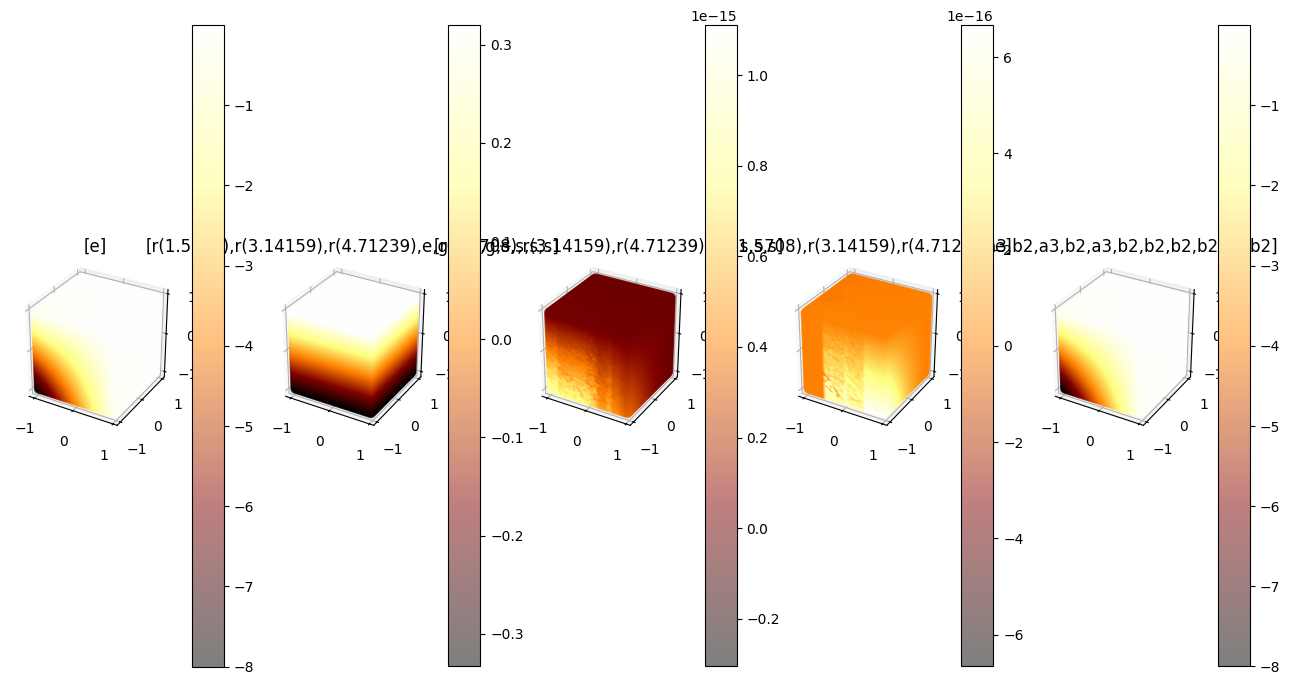

In [9]:
ndim = 3
# ndim-unit cube
domain = onp.array([(-1, 1)]*ndim)
center = 0.5 * (domain[:,1] - domain[:,0])
# zero element
_0 = onp.zeros(ndim)

N = cfg.res_3d
xi = onp.array([onp.linspace(d[0], d[1], N, endpoint=False) for d in domain]) - center[:, None]
grid = onp.meshgrid(*xi)
coords = onp.vstack([x.ravel() for x in grid]).T + center

# ---- Rotations ----
rot_order = 4
dθ = 2 * onp.pi / rot_order
qRM = sym.rotation3d
p4 = [qRM(i * dθ, B.e3) for i in range(1, rot_order)]

p4.append(sym.identity(ndim))
# Glide Reflections
gl_ref = sym.glide_reflection
g =[
	gl_ref(B.e1, center),
	gl_ref(B.e2, center),
	gl_ref(B.e1 - B.e2, center),
	gl_ref(B.e1 + B.e2, center),
]

# Reflections
ref = lambda n: sym.reflection(n)
m = [
	ref(B.e1),
	ref(B.e2),
	ref(B.e1 - B.e2),
	ref(B.e1 + B.e2),
]
Gp4 = sym.FiniteGroupAction(tuple(p4), name="p4")
Gp4m = sym.FiniteGroupAction((*p4, *m), name="p4m")
Gp4gm = sym.FiniteGroupAction((*p4, *g, *m), name="p4gm")

A4 = sym.tetrahedral_group()

plot_func(func_xyz, *grid, center=center, sym_ops=[Gp4gm, Gp4m, Gp4, A4])

In [ ]:
sym_ops = [sym.identity(ndim)]

# Reflections
m = [
	ref(B.e1),
	ref(B.e2),
	ref(B.e3),
]

rot_order = 3
dtheta3 = 2 * onp.pi / rot_order
qRM = sym.rotation3d
rot_3fold_1 = [qRM(i * dtheta3, B.e1 + B.e2 + B.e3) for i in range(1, rot_order)]
rot_3fold_2 = [qRM(i * dtheta3, B.e1 - B.e2 + B.e3) for i in range(1, rot_order)]
rot_3fold_3 = [qRM(i * dtheta3, - B.e1 + B.e2 + B.e3) for i in range(1, rot_order)]
rot_3fold_4 = [qRM(i * dtheta3, - B.e1 - B.e2 + B.e3) for i in range(1, rot_order)]

rot_order = 2
dtheta2 = 2 * onp.pi / rot_order
rot_2fold_x = [qRM(i * dtheta2, B.e1) for i in range(1, rot_order)]
rot_2fold_y = [qRM(i * dtheta2, B.e2) for i in range(1, rot_order)]
rot_2fold_z = [qRM(i * dtheta2, B.e3) for i in range(1, rot_order)]


sym_ops += m
sym_ops += rot_2fold_x + rot_2fold_y + rot_2fold_z
sym_ops += rot_3fold_1 + rot_3fold_2 + rot_3fold_3 + rot_3fold_4

sym_ops.append(sym.identity(ndim, inversion=True))
plot_func(func3D, *grid, center=center, sym_ops=[sym_ops, sym_ops])

In [ ]:
polyhedron_verts = [
	[0, 0, 0],
	[1, 0, 0],
	[0, 1, 0],
	[0, 0, 1],
	[1, 1, 0],
	[1, 0, 1],
	[0, 1, 1],
	[1, 1, 1],
]

tetrahedron_verts = [
	[0, 0, 0],
	[0.5, 0, 0],
	[0, 0.5, 0],
	[0, 0, 0.5],
]

polyhedron = onp.array(polyhedron_verts, dtype=onp.float64)

polyhedron = polyhedron - cfuncs.polyhedron_centroid(polyhedron)
polyhedron = cfuncs.scale_poly(polyhedron)

tetra = onp.array(tetrahedron_verts, dtype=onp.float64)



In [ ]:
f_sym = sym.symmetrize(func3D, *grid, sym_ops=sym_ops)
alpha = 0.9 * onp.ones(4)
tetra_scaled = cfuncs.scale_poly(tetra)
dist, dist_weights = cfuncs.weighted_distribution(
    f_sym,
    coords.T,
    tetra_scaled,
    alpha=alpha,
    n_samples=cfg.n_samples_fast,
    rng=cfg.seed + 3,
)


In [ ]:
plot_weighted_dist(f_sym, coords.T, tetra_scaled, n_samples=cfg.n_samples_plot, rng=cfg.seed + 4)


In [ ]:
cent = cfuncs.simplex_centroid(tetra_scaled)
tetra_for_mapping = tetra_scaled - cent
dist_for_mapping = dist - cent

piecewise_matrices, triangulations, simps, dst, src = cfuncs.collect_matrices(
    tetra_for_mapping,
    polyhedron,
    num_rots=12,
)

mapping_counts = {
    "matrices": len(piecewise_matrices),
    "triangulations": len(triangulations),
    "src": len(src),
    "dst": len(dst),
}
min_idx = cfuncs.minimize_jacobian(piecewise_matrices, dst, simps, src)
best_mat = piecewise_matrices[min_idx]
best_map = dst[min_idx]
best_tri = triangulations[min_idx]
best_poly = src[min_idx]


In [ ]:
# inv_mats is computed in the plotting cell below.

In [ ]:
plot_result(best_map, best_mat, best_poly, best_tri, dist_for_mapping, dist_weights)


In [ ]:
fig = plt.figure(figsize=(12, 12))
ax: Axes3D = fig.add_subplot(111, projection="3d")

ax.scatter(*dist_for_mapping.T, c=dist_weights, s=50, cmap=cmap, alpha=0.05, edgecolors="none", linewidths=0)

for tet in best_tri.simplices:
	faces = ConvexHull(best_map[tet]).simplices
	plot_simplex(best_poly, ax, simplices=faces, color="r", linestyle="")
	plot_simplex(best_map, ax, simplices=faces, color="r", linestyle="")

plot_simplex(best_poly, ax, color="c", show_faces=True)
plot_simplex(best_map, ax, simplices=ConvexHull(best_poly).simplices, color="r")
plot_simplex(best_map, ax, color="k")

end_pts = best_map - best_poly
ax.quiver(*best_poly.T, *end_pts.T, length=1, arrow_length_ratio=0.1)
ax.set_aspect("equal")
ax.view_init(0, 0, 0)

inv_mats = onp.array([onp.linalg.inv(M) for M in best_mat])

fig = plt.figure(figsize=(12, 12))
ax: Axes3D = fig.add_subplot(111, projection="3d")

dst_idxs = best_tri.find_simplex(dist_for_mapping)
outside = dst_idxs < 0
if onp.any(outside):
	raise ValueError(f"{outside.sum()} distribution points are outside the triangulation")

affine_map = onp.array([
	cfuncs.apply_affine_mat(pt, inv_mats[idx])
	for pt, idx in zip(dist_for_mapping, dst_idxs)
])
ax.scatter(*affine_map.T, c=dist_weights, s=50, cmap=cmap, alpha=0.1, edgecolors="none", linewidths=0)

faces = ConvexHull(best_poly).simplices
for face in faces:
	vs = onp.array(list(best_poly[face]) + [best_poly[face][0]])
	ax.plot(*vs.T, "ko-")
	parametrization = cfuncs.parametrize_triangle(*best_poly[face], num_points=100)
	ax.scatter(*parametrization.T, c="k", s=10, alpha=0.025)

ax.set_aspect("equal")
ax.set_proj_type("persp")
ax.view_init(0, 0, 0)
